# **Driver drowsiness system**

Dataset Links:
- https://www.kaggle.com/datasets/samymesbah/nthu-dataset-ddd-multi-class

#### **Dataset Downloads**

**Google Colab**

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"efficient8","key":"0e26061c5d5cf73b850e01f7c6575016"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d samymesbah/nthu-dataset-ddd-multi-class

Dataset URL: https://www.kaggle.com/datasets/samymesbah/nthu-dataset-ddd-multi-class
License(s): unknown
100% 1.99G/1.99G [00:18<00:00, 117MB/s] 



In [5]:
!unzip -q nthu-dataset-ddd-multi-class.zip

**Libraries**

In [6]:
import os
import shutil
import warnings
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

warnings.filterwarnings('ignore')

#### **Rearranging Dataset Directory**

In [9]:
root_dir = "Multi class"
drowsy_dir = "Multi class/train/drowsy"
nondrowsy_dir = "Multi class/train/notdrowsy"

In [10]:
# Moving all classes in drowsy to datasets

for d in os.listdir(drowsy_dir):
    src_path = os.path.join(drowsy_dir, d)
    dst_path = root_dir
    shutil.move(src_path, dst_path)


In [11]:
shutil.move(nondrowsy_dir, root_dir)

'Multi class/notdrowsy'

In [12]:
shutil.rmtree(drowsy_dir)
shutil.rmtree("Multi class/train")

#### **Final Dataset**

In [13]:
parent_dir = "Multi class"

In [14]:
# Count of images in each class

count_of_images = {}
for l in os.listdir(parent_dir):
    count_of_images[l] = len(os.listdir(os.path.join(dst_path, l)))

In [15]:
count_of_images

{'slowBlinkWithNodding': 9412,
 'yawning': 8862,
 'notdrowsy': 30491,
 'sleepyCombination': 17756}

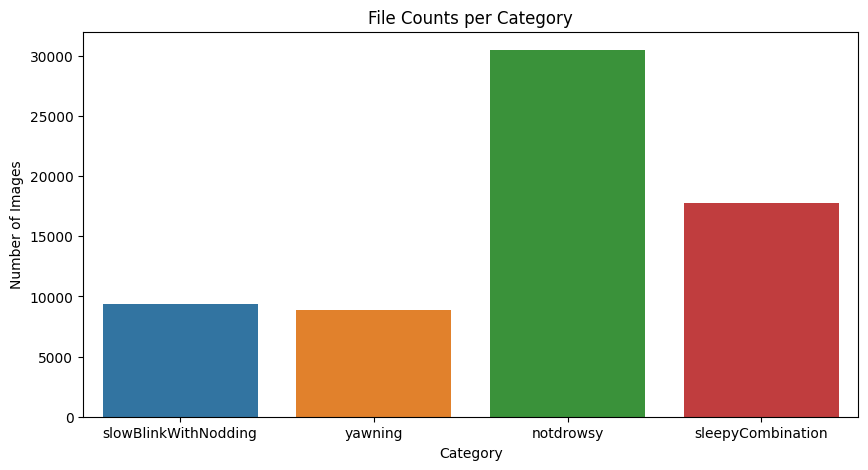

In [16]:
plt.figure(figsize=(10, 5))
sns.barplot(x=count_of_images.keys(), y=count_of_images.values(), hue=count_of_images.keys())
plt.title('File Counts per Category')
plt.ylabel('Number of Images')
plt.xlabel('Category')
plt.show()

**Sample Data Visualization**

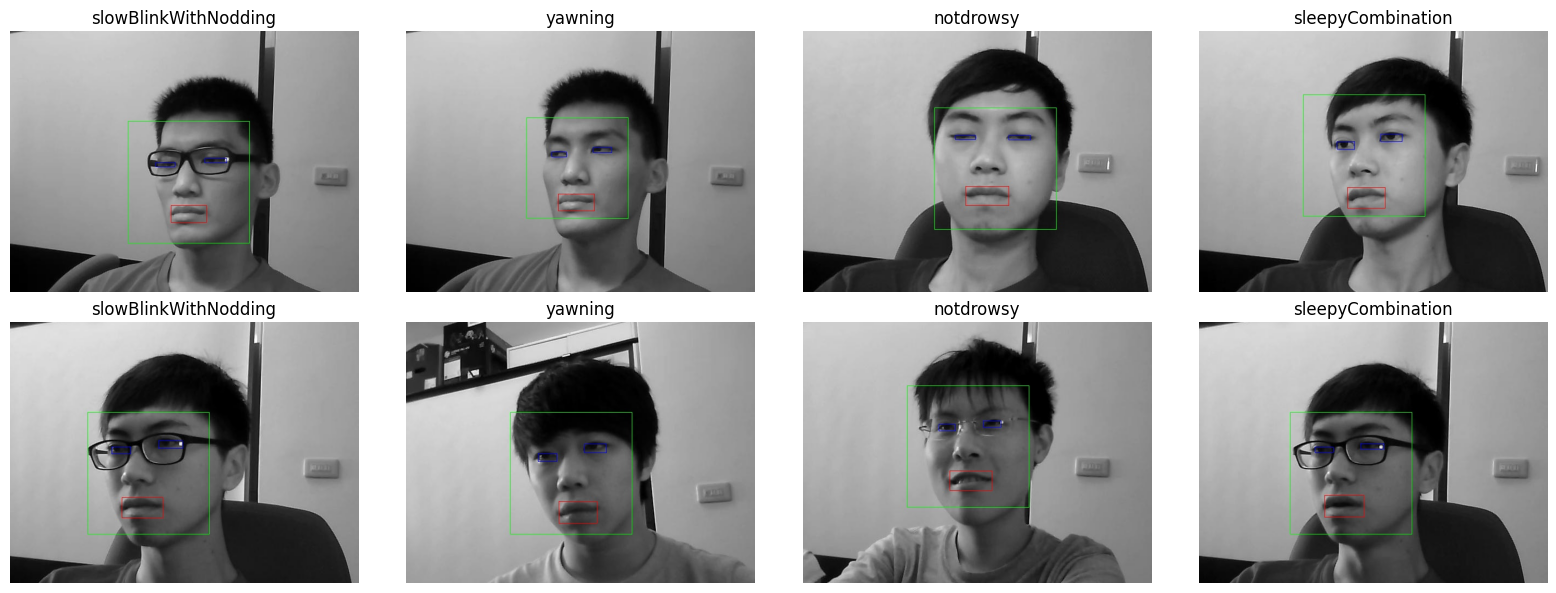

In [18]:
import matplotlib.image as mpimg
dst_path = parent_dir
categories = os.listdir(dst_path)
dir_path = 'Multi class'

fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for i, category in enumerate(categories):
    folder = os.path.join(dir_path, category)
    images = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
    sample_imgs = random.sample(images, 2) if len(images) >= 2 else images
    for j, img_name in enumerate(sample_imgs):

        ax = axes[j, i]
        img_path = os.path.join(folder, img_name)
        img = mpimg.imread(img_path)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"{category}")
        ax.axis('off')

    for j in range(len(sample_imgs), 2):
        axes[j, i].axis('off')

plt.tight_layout()
plt.show()


**Train, Test and Validation**

In [19]:
# Paths
source_dir = "Multi class"
target_dir = "Model Data"

classes = categories

# Create folder structure
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(target_dir, split, cls), exist_ok=True)

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for cls in classes:
    class_path = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(class_path) if f.endswith(".jpg")]

    random.shuffle(images)

    total = len(images)
    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    # Copy files
    for img in train_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "train", cls, img)
        )

    for img in val_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "val", cls, img)
        )

    for img in test_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "test", cls, img)
        )

print("Dataset successfully split into Train (70%), Val (15%), Test (15%)")

Dataset successfully split into Train (70%), Val (15%), Test (15%)


**Data after train, test and validation split**

In [20]:
train_parent_dir = "Model Data/train"
print("Count of Images for each class in train directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(train_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in train directory
slowBlinkWithNodding has 6588 images
yawning has 6203 images
notdrowsy has 21343 images
sleepyCombination has 12429 images


In [21]:
val_parent_dir = "Model Data/val"
print("Count of Images for each class in val directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(val_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in val directory
slowBlinkWithNodding has 1411 images
yawning has 1329 images
notdrowsy has 4573 images
sleepyCombination has 2663 images


In [22]:
test_parent_dir = "Model Data/test"
print("Count of Images for each class in test directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(test_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in test directory
slowBlinkWithNodding has 1413 images
yawning has 1330 images
notdrowsy has 4575 images
sleepyCombination has 2664 images


#### **Data Augmentation**

In [87]:
train_dir = "Model Data/train"
val_dir = "Model Data/val"
test_dir = "Model Data/test"

In [88]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [89]:
img_dims = (128, 128)
batch_size = 64

In [90]:
train_data = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_generator = train_data.flow_from_directory(
    directory=train_dir,
    target_size= img_dims,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical'
)

Found 46563 images belonging to 4 classes.


In [91]:
val_test_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_test_datagen.flow_from_directory(
    directory=val_dir,
    target_size=img_dims,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical'
)

Found 9976 images belonging to 4 classes.


In [92]:
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_dims,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 9982 images belonging to 4 classes.


In [93]:
train_generator.class_indices

{'notdrowsy': 0,
 'sleepyCombination': 1,
 'slowBlinkWithNodding': 2,
 'yawning': 3}

## **Models**

In [94]:
from collections import Counter

# Get class labels
class_labels = train_generator.class_indices
print("Class Labels:", class_labels)

# Count samples
counts = Counter(train_generator.classes)

# Imbalance Ratio
counts_list = np.array(list(counts.values()))

imbalance_ratio = counts_list.max() / counts_list.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")

Class Labels: {'notdrowsy': 0, 'sleepyCombination': 1, 'slowBlinkWithNodding': 2, 'yawning': 3}

Imbalance Ratio: 3.44


In [95]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights)


Class Weights: {0: np.float64(0.5454130159771353), 1: np.float64(0.936579773111272), 2: np.float64(1.7669626593806922), 3: np.float64(1.8766322747057875)}


In [96]:
class_len = train_generator.num_classes
epochs = 10

In [97]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.3, patience=3)
]

In [98]:
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
import random

#### **CNN**

In [99]:
def build_custom_cnn(input_shape=(img_dims[0],img_dims[1],3), num_classes= len(train_generator.class_indices)):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(class_len, activation='softmax')
    ])
    return model

In [100]:
custom_model = build_custom_cnn()
custom_model.compile(optimizer=Adam(0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

In [101]:
history_custom = custom_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 288s 389ms/step - accuracy: 0.3220 - loss: 1.3114 - val_accuracy: 0.4477 - val_loss: 1.1859 - learning_rate: 0.0010
Epoch 2/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 275s 378ms/step - accuracy: 0.4597 - loss: 1.0760 - val_accuracy: 0.6099 - val_loss: 0.8860 - learning_rate: 0.0010
Epoch 3/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 273s 376ms/step - accuracy: 0.5506 - loss: 0.9006 - val_accuracy: 0.6353 - val_loss: 0.8514 - learning_rate: 0.0010
Epoch 4/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 276s 379ms/step - accuracy: 0.6243 - loss: 0.7708 - val_accuracy: 0.7074 - val_loss: 0.7202 - learning_rate: 0.0010
Epoch 5/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 279s 383ms/step - accuracy: 0.6683 - loss: 0.6899 - val_accuracy: 0.7193 - val_loss: 0.7945 - learning_rate: 0.0010
Epoch 6/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 284s 390ms/step - accuracy: 0.7036 - loss: 0.6251 - val_accuracy: 0.7663 - val_loss: 0.6152 - learning_rate: 0.0010
Epoch 7/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 278s 381ms/step - accura

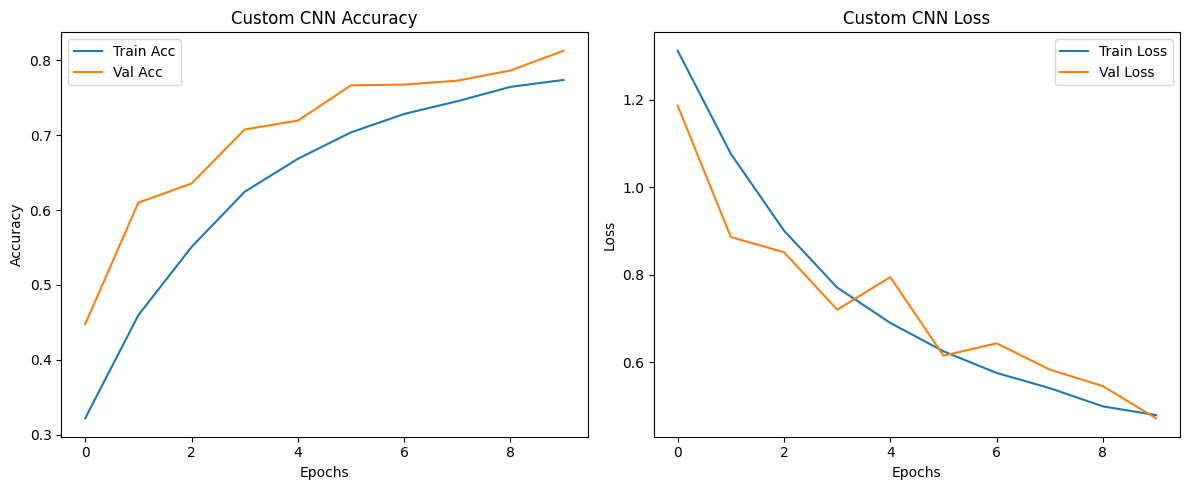

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Plot
axes[0].plot(history_custom.history['accuracy'], label='Train Acc')
axes[0].plot(history_custom.history['val_accuracy'], label='Val Acc')
axes[0].set_title("Custom CNN Accuracy")
axes[0].legend()
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")

# Loss Plot
axes[1].plot(history_custom.history['loss'], label='Train Loss')
axes[1].plot(history_custom.history['val_loss'], label='Val Loss')
axes[1].set_title("Custom CNN Loss")
axes[1].legend()
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

#### **MobileNetV2**

In [103]:
base_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_dims[0],img_dims[1],3))
base_mobilenet.trainable = False

x = base_mobilenet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(class_len, activation='softmax')(x)

mobilenet_model = Model(inputs=base_mobilenet.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [104]:
mobilenet_model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [105]:
history_mob = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks,
    epochs=epochs
)

Epoch 1/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 325s 422ms/step - accuracy: 0.6026 - loss: 0.8867 - val_accuracy: 0.6655 - val_loss: 0.8607 - learning_rate: 0.0010
Epoch 2/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 275s 377ms/step - accuracy: 0.7107 - loss: 0.6542 - val_accuracy: 0.6973 - val_loss: 0.8103 - learning_rate: 0.0010
Epoch 3/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 274s 377ms/step - accuracy: 0.7465 - loss: 0.5680 - val_accuracy: 0.6725 - val_loss: 0.8305 - learning_rate: 0.0010


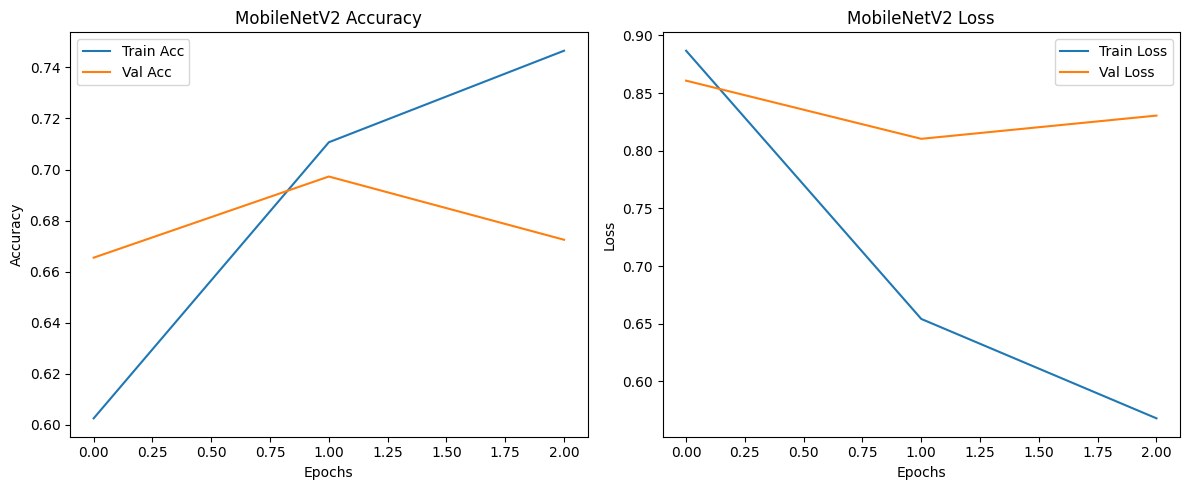

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Plot
axes[0].plot(history_mob.history['accuracy'], label='Train Acc')
axes[0].plot(history_mob.history['val_accuracy'], label='Val Acc')
axes[0].set_title("MobileNetV2 Accuracy")
axes[0].legend()
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")

# Loss Plot
axes[1].plot(history_mob.history['loss'], label='Train Loss')
axes[1].plot(history_mob.history['val_loss'], label='Val Loss')
axes[1].set_title("MobileNetV2 Loss")
axes[1].legend()
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

In [107]:
for layer in base_mobilenet.layers[-30:]:
    layer.trainable = True

mobilenet_model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

In [108]:
history_mob_ft = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks,
    epochs=epochs
)

Epoch 1/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 304s 396ms/step - accuracy: 0.6359 - loss: 0.9593 - val_accuracy: 0.6029 - val_loss: 1.1475 - learning_rate: 1.0000e-05
Epoch 2/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 281s 385ms/step - accuracy: 0.7169 - loss: 0.6329 - val_accuracy: 0.6374 - val_loss: 1.0368 - learning_rate: 1.0000e-05
Epoch 3/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 272s 373ms/step - accuracy: 0.7610 - loss: 0.5346 - val_accuracy: 0.6838 - val_loss: 0.9021 - learning_rate: 1.0000e-05


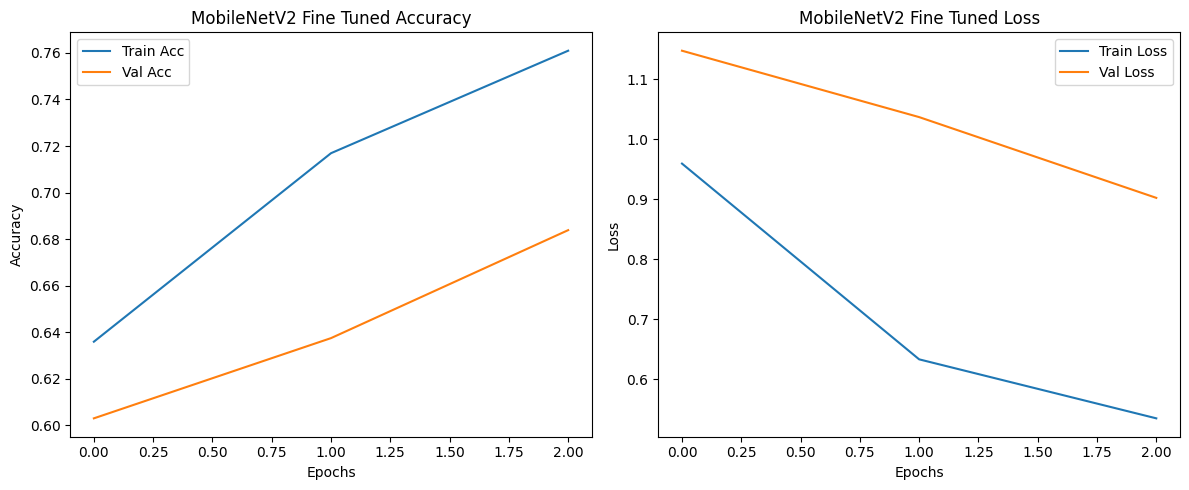

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Plot
axes[0].plot(history_mob_ft.history['accuracy'], label='Train Acc')
axes[0].plot(history_mob_ft.history['val_accuracy'], label='Val Acc')
axes[0].set_title("MobileNetV2 Fine Tuned Accuracy")
axes[0].legend()
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")

# Loss Plot
axes[1].plot(history_mob_ft.history['loss'], label='Train Loss')
axes[1].plot(history_mob_ft.history['val_loss'], label='Val Loss')
axes[1].set_title("MobileNetV2 Fine Tuned Loss")
axes[1].legend()
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

#### **VGG201**

In [110]:
from tensorflow.keras.applications import VGG16

In [111]:
vgg_base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_dims[0], img_dims[1], 3))

# Freeze the convolutional base
vgg_base_model.trainable = False

# Build your model
vgg_model = Sequential([
    vgg_base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(class_len, activation='softmax')
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [112]:
vgg_model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

In [113]:
history_vgg = vgg_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 337s 441ms/step - accuracy: 0.3412 - loss: 1.3587 - val_accuracy: 0.4602 - val_loss: 1.2298 - learning_rate: 1.0000e-05
Epoch 2/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 306s 421ms/step - accuracy: 0.4532 - loss: 1.1854 - val_accuracy: 0.5417 - val_loss: 1.0905 - learning_rate: 1.0000e-05
Epoch 3/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 303s 416ms/step - accuracy: 0.5197 - loss: 1.0846 - val_accuracy: 0.6264 - val_loss: 0.9663 - learning_rate: 1.0000e-05


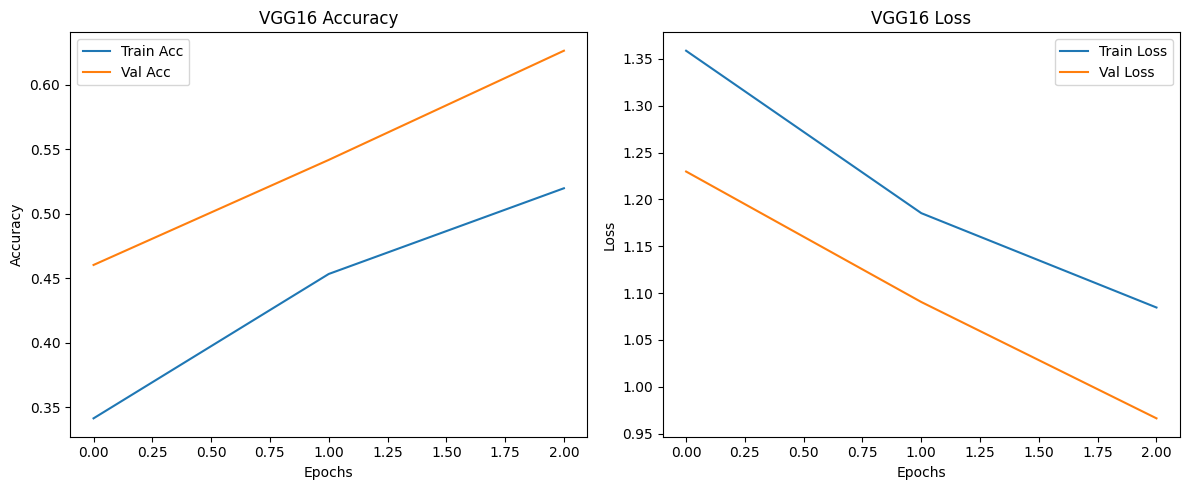

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Plot
axes[0].plot(history_vgg.history['accuracy'], label='Train Acc')
axes[0].plot(history_vgg.history['val_accuracy'], label='Val Acc')
axes[0].set_title("VGG16 Accuracy")
axes[0].legend()
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")

# Loss Plot
axes[1].plot(history_vgg.history['loss'], label='Train Loss')
axes[1].plot(history_vgg.history['val_loss'], label='Val Loss')
axes[1].set_title("VGG16 Loss")
axes[1].legend()
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

#### **ResNet50**

In [115]:
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(img_dims[0],img_dims[1],3))
base_resnet.trainable = False

x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(class_len, activation='softmax')(x)

resnet_model = Model(inputs=base_resnet.input, outputs=output)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [116]:
resnet_model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [117]:
history_res = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 307s 406ms/step - accuracy: 0.2644 - loss: 1.3870 - val_accuracy: 0.1948 - val_loss: 1.4185 - learning_rate: 0.0010
Epoch 2/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 299s 411ms/step - accuracy: 0.2770 - loss: 1.3675 - val_accuracy: 0.2551 - val_loss: 1.3899 - learning_rate: 0.0010
Epoch 3/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 310s 394ms/step - accuracy: 0.2900 - loss: 1.3499 - val_accuracy: 0.2062 - val_loss: 1.3764 - learning_rate: 0.0010


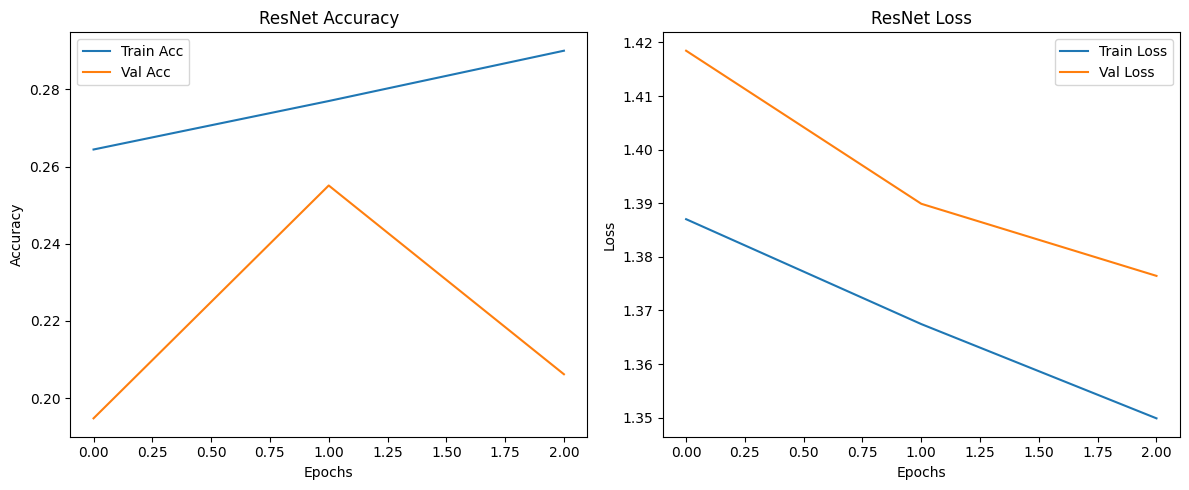

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Plot
axes[0].plot(history_res.history['accuracy'], label='Train Acc')
axes[0].plot(history_res.history['val_accuracy'], label='Val Acc')
axes[0].set_title("ResNet Accuracy")
axes[0].legend()
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")

# Loss Plot
axes[1].plot(history_res.history['loss'], label='Train Loss')
axes[1].plot(history_res.history['val_loss'], label='Val Loss')
axes[1].set_title("ResNet Loss")
axes[1].legend()
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

#### **DenseNet201**

In [119]:
from tensorflow.keras.applications import DenseNet201

In [121]:
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(img_dims[0], img_dims[1], 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(class_len, activation='softmax')(x)

densenet_model = Model(inputs=base_model.input, outputs=x)

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [122]:
densenet_model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history_dense = densenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 414s 507ms/step - accuracy: 0.5125 - loss: 1.0625 - val_accuracy: 0.6332 - val_loss: 0.8674 - learning_rate: 0.0010
Epoch 2/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 298s 409ms/step - accuracy: 0.6274 - loss: 0.8130 - val_accuracy: 0.7126 - val_loss: 0.7476 - learning_rate: 0.0010
Epoch 3/10
414/728 ━━━━━━━━━━━━━━━━━━━━ 2:01 388ms/step - accuracy: 0.6649 - loss: 0.7368

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Plot
axes[0].plot(history_dense.history['accuracy'], label='Train Acc')
axes[0].plot(history_dense.history['val_accuracy'], label='Val Acc')
axes[0].set_title("DenseNet201 Accuracy")
axes[0].legend()
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")

# Loss Plot
axes[1].plot(history_dense.history['loss'], label='Train Loss')
axes[1].plot(history_dense.history['val_loss'], label='Val Loss')
axes[1].set_title("DenseNet201 Loss")
axes[1].legend()
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

## **Metrics**

In [ ]:
def evaluate_model(model, name):
    y_true = test_generator.classes
    y_pred = np.argmax(model.predict(test_generator), axis=1)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return [name, acc, prec, rec, f1], y_true, y_pred

In [ ]:
model_results = []

cnn_metrics, y_true, y_pred_cnn = evaluate_model(custom_model, "Custom CNN")
model_results.append(cnn_metrics)

In [ ]:
mob_metrics, _, y_pred_mob = evaluate_model(mobilenet_model, "MobileNetV2")
model_results.append(mob_metrics)

In [ ]:
vgg_metrics, _, y_pred_vgg = evaluate_model(vgg_model, "VGG16")
model_results.append(vgg_metrics)

In [ ]:
res_metrics, _, y_pred_res = evaluate_model(resnet_model, "ResNet50")
model_results.append(res_metrics)

In [ ]:
dense_metrics, _, y_pred_dense = evaluate_model(densenet_model, "DenseNet201")
model_results.append(dense_metrics)

In [ ]:
df_results = pd.DataFrame(model_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
df_results

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=df_results, palette='flare')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Precision', data=df_results, palette='flare')
plt.title('Model Precision Comparison')
plt.xlabel('Model')
plt.ylabel('Precision')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Recall', data=df_results, palette='flare')
plt.title('Model Recall Comparison')
plt.xlabel('Model')
plt.ylabel('Recall')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='F1', data=df_results, palette='flare')
plt.title('Model F1 Comparison')
plt.xlabel('Model')
plt.ylabel('F1')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **Confusion Matrix**

In [ ]:
cm_cnn = confusion_matrix(y_true, y_pred_cnn)

sns.heatmap(cm_cnn, annot=True, fmt='d')
plt.title("Confusion Matrix for Custom CNN Model")
plt.show()

In [ ]:
cm_mob = confusion_matrix(y_true, y_pred_mob)
sns.heatmap(cm_mob, annot=True, fmt='d')
plt.title("Confusion Matrix for MobileNetV2 Model")
plt.show()

In [ ]:
cm_res = confusion_matrix(y_true, y_pred_res)

sns.heatmap(cm_res, annot=True, fmt='d')
plt.title("Confusion Matrix for ResNet Model")
plt.show()

In [ ]:
cm_vgg = confusion_matrix(y_true, y_pred_vgg)

sns.heatmap(cm_vgg, annot=True, fmt='d')
plt.title("Confusion Matrix for VGG Model")
plt.show()

In [ ]:
cm_dense = confusion_matrix(y_true, y_pred_dense)

sns.heatmap(cm_dense, annot=True, fmt='d')
plt.title("Confusion Matrix for DenseNet201 Model")
plt.show()

## **ROC Curve**

In [ ]:
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
y_pred_prob = custom_model.predict(test_generator)

fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC Curve for Custom CNN")
plt.show()

In [ ]:
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
y_pred_prob = mobilenet_model.predict(test_generator)

fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC Curve for MobileNetV2")
plt.show()

In [ ]:
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
y_pred_prob = resnet_model.predict(test_generator)

fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC Curve for ResNet Model")
plt.show()

In [ ]:
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
y_pred_prob = vgg_model.predict(test_generator)

fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC Curve for VGG Model")
plt.show()

In [ ]:
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
y_pred_prob = densenet_model.predict(test_generator)

fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC Curve for DenseNet201 Model")
plt.show()

## **Test Predictions**

In [ ]:
best_model_name = df_results.sort_values(by="F1", ascending=False).iloc[0]["Model"]
print("Best Model:", best_model_name)

In [ ]:
class_labels = list(test_generator.class_indices.keys())
best_model = mobilenet_model
for i in range(5):
    img, label = test_generator[i]
    pred = best_model.predict(img)

    plt.imshow(img[0])
    plt.title(f"Actual: {class_labels[np.argmax(label[0])]} | Pred: {class_labels[np.argmax(pred[0])]}")
    plt.axis('off')
    plt.show()

## **Grad-CAM**

In [ ]:
def grad_cam(model, img_array, layer_name):
    grad_model = Model([model.inputs], [model.get_layer(layer_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, np.argmax(predictions[0])]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap

In [ ]:
img, _ = test_generator[0]
heatmap = grad_cam(best_model, img, layer_name=best_model.layers[-5].name)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original Image
axes[0].imshow(img[0])
axes[0].set_title("Original Image")
axes[0].axis('off')

# Grad-CAM
axes[1].imshow(img[0])
axes[1].imshow(heatmap, cmap='jet', alpha=0.5)
axes[1].set_title("Grad-CAM")
axes[1].axis('off')

plt.tight_layout()
plt.show()